
# Inhibitory modulation of dynamics along a connectomic backbone

This notebook analyzes how negative/inhibitory connectivity modulates dynamics around a fixed directed backbone.

The dynamical model is

\[
\dot{\mathbf x}=A(g)\mathbf x+\mathbf u(t),
\qquad
A(g)=-\alpha I+\beta\left(W_E-gW_I\right),
\]

where \(W_E\ge 0\) contains excitatory weights, \(W_I\ge 0\) contains inhibitory magnitudes, \(g\) scales inhibition, \(\alpha\) is intrinsic decay, and \(\beta\) sets global coupling.

The notebook follows this workflow:

1. Load and validate the signed directed matrix.
2. Convert it to the state-space orientation \(W_{\text{target},\text{source}}\).
3. Define a fixed backbone ordering.
4. Split excitation and inhibition.
5. Inject an impulse at the start of the backbone.
6. Measure propagation amplitude, integrated activity, and arrival time.
7. Sweep inhibitory strength \(g\).
8. Examine eigenvalue stability and transient amplification.
9. Ablate inhibitory neurons and inhibitory edges.
10. Classify inhibitory edges as feedforward/feedback relative to backbone position.
11. Compare the observed inhibitory organization with randomized nulls.

> **Important:** Replace `BACKBONE_LABELS` with your actual backbone ordering before interpreting results biologically.


In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.linalg import eigvals, expm, svdvals
from scipy.sparse.linalg import expm_multiply

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_rows", 100)


## 1. Load and validate the connectomic matrix

In [6]:

MATRIX_PATH = Path("matrices/mij_matrix.csv")

# Orientation of the CSV:
# "source_rows"  -> CSV entry [i,j] means source i -> target j
# "target_rows"  -> CSV entry [i,j] means source j -> target i
CSV_ORIENTATION = "source_rows"

raw = pd.read_csv(MATRIX_PATH, header=None)

row_labels = raw.iloc[1:, 0].astype(str).tolist()
col_labels = raw.iloc[0, 1:].astype(str).tolist()
W_csv = (
    raw.iloc[1:, 1:]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float, copy=True)
)
assert W_csv.shape[0] == W_csv.shape[1], "Matrix must be square."
assert len(row_labels) == W_csv.shape[0] == len(col_labels), "Label dimensions do not match matrix."
assert row_labels == col_labels, "Row and column labels differ; inspect ordering before proceeding."
assert np.isfinite(W_csv).all(), "Matrix contains NaN/Inf values."

np.fill_diagonal(W_csv, 0.0)
labels = row_labels
n = len(labels)

summary = pd.Series({
    "nodes": n,
    "positive edges": int((W_csv > 0).sum()),
    "negative edges": int((W_csv < 0).sum()),
    "zero entries": int((W_csv == 0).sum()),
    "nonzero density (off-diagonal)": float((W_csv != 0).sum() / (n*(n-1))),
    "minimum weight": float(W_csv.min()),
    "maximum weight": float(W_csv.max()),
})
display(summary)


nodes                             8.500000e+01
positive edges                    7.070000e+02
negative edges                    8.630000e+02
zero entries                      5.655000e+03
nonzero density (off-diagonal)    2.198880e-01
minimum weight                   -3.610668e+03
maximum weight                    1.227403e+06
dtype: float64


### State-space orientation

Throughout the dynamics below, the convention is

\[
\dot x_i=\sum_j A_{ij}x_j,
\]

so **column \(j\)** is the source and **row \(i\)** is the target. Thus \(W_{ij}\) means \(j\to i\).

If your CSV instead stores source neurons in rows, the matrix must be transposed once.


In [7]:

if CSV_ORIENTATION == "source_rows":
    W_state_raw = W_csv.T.copy()
elif CSV_ORIENTATION == "target_rows":
    W_state_raw = W_csv.copy()
else:
    raise ValueError("CSV_ORIENTATION must be 'source_rows' or 'target_rows'.")

# Quick sign/scale report
nonzero = W_state_raw[W_state_raw != 0]
display(pd.Series({
    "|weight| median": np.median(np.abs(nonzero)),
    "|weight| 95th percentile": np.quantile(np.abs(nonzero), 0.95),
    "|weight| maximum": np.max(np.abs(nonzero)),
}))


|weight| median             1.101414e+02
|weight| 95th percentile    2.394046e+04
|weight| maximum            1.227403e+06
dtype: float64

## 2. Define the backbone

In [8]:

# Replace this with your actual Hamiltonian/backbone ordering, e.g.
# BACKBONE_LABELS = ["cell A", "cell B", "cell C", ...]
#
# If left as None, the notebook uses the CSV label order ONLY as a runnable placeholder.
BACKBONE_LABELS = None

if BACKBONE_LABELS is None:
    backbone = labels.copy()
    print("WARNING: using CSV label order as a placeholder backbone.")
else:
    missing = [x for x in BACKBONE_LABELS if x not in labels]
    if missing:
        raise ValueError(f"Backbone labels not found in matrix: {missing[:10]}")
    if len(set(BACKBONE_LABELS)) != len(BACKBONE_LABELS):
        raise ValueError("Backbone contains duplicate nodes.")
    backbone = list(BACKBONE_LABELS)

idx = {lab: i for i, lab in enumerate(labels)}
backbone_idx = np.array([idx[x] for x in backbone], dtype=int)
position = {node: k for k, node in enumerate(backbone)}

print(f"Backbone length: {len(backbone)}")
print("First 10 nodes:", backbone[:10])


Backbone length: 85
First 10 nodes: ['CA1 Axo Axonic', 'CA1 Back Projection', 'CA1 Basket', 'CA1 Basket CCK+', 'CA1 Bistratified', 'CA1 Horizontal Axo Axonic', 'CA1 Horizontal Basket', 'CA1 Ivy', 'CA1 LMR', 'CA1 Neurogliaform']



## 3. Normalize scale and split excitation/inhibition

Because the supplied matrix spans a large numerical range, raw weights can make the linear system numerically explosive. We therefore separate **topology/sign** from an explicit global coupling parameter.

The normalized connectivity is

\[
\widehat W=\frac{W}{s},
\]

where \(s\) is the 95th percentile of nonzero \(|W_{ij}|\). This is robust to very large outliers. You can change the scaling rule if the absolute units of your weights are already dynamically meaningful.


In [9]:

abs_nonzero = np.abs(W_state_raw[W_state_raw != 0])
SCALE = np.quantile(abs_nonzero, 0.95)
W = W_state_raw / SCALE

W_E = np.maximum(W, 0.0)
W_I = np.maximum(-W, 0.0)  # inhibitory magnitudes, always nonnegative

ALPHA = 1.0   # intrinsic decay/leak
BETA = 0.8    # global network coupling

def system_matrix(g=1.0, W_E_=W_E, W_I_=W_I, alpha=ALPHA, beta=BETA):
    return -alpha * np.eye(n) + beta * (W_E_ - g * W_I_)

print(f"Normalization scale = {SCALE:.4g}")
print(f"Excitatory edges = {(W_E > 0).sum()}")
print(f"Inhibitory edges = {(W_I > 0).sum()}")


Normalization scale = 2.394e+04
Excitatory edges = 707
Inhibitory edges = 863


### Optional Dale-law diagnostic

In [10]:

# In state-space orientation, outgoing edges from source j are in column j.
dale_rows = []
for j, lab in enumerate(labels):
    out = W[:, j]
    nz = out[out != 0]
    if len(nz) == 0:
        frac_pos = frac_neg = np.nan
        classification = "isolated/no outgoing"
    else:
        frac_pos = np.mean(nz > 0)
        frac_neg = np.mean(nz < 0)
        if frac_neg >= 0.9:
            classification = "mostly inhibitory"
        elif frac_pos >= 0.9:
            classification = "mostly excitatory"
        else:
            classification = "mixed-sign"
    dale_rows.append((lab, len(nz), frac_pos, frac_neg, classification))

dale = pd.DataFrame(
    dale_rows,
    columns=["node", "out_degree", "fraction_positive", "fraction_negative", "classification"]
)
display(dale["classification"].value_counts())
display(dale.sort_values("fraction_negative", ascending=False).head(15))


classification
mostly inhibitory    53
mostly excitatory    32
Name: count, dtype: int64

,node,out_degree,fraction_positive,fraction_negative,classification
0,CA1 Axo Axonic,2,0.0,1.0,mostly inhibitory
28,CA2 Basket,4,0.0,1.0,mostly inhibitory
31,CA2 SP SR,4,0.0,1.0,mostly inhibitory
32,CA2 Wide Arbor Basket,20,0.0,1.0,mostly inhibitory
33,CA3 Axo Axonic,2,0.0,1.0,mostly inhibitory
34,CA3 Basket,5,0.0,1.0,mostly inhibitory
35,CA3 Basket CCK+,5,0.0,1.0,mostly inhibitory
37,CA3 Horizontal Axo Axonic,2,0.0,1.0,mostly inhibitory
38,CA3 LMR Targeting,9,0.0,1.0,mostly inhibitory
39,CA3 Lucidum ORAX,14,0.0,1.0,mostly inhibitory



## 4. Impulse propagation along the backbone

We stimulate the first backbone node with a unit impulse. For an impulse at \(t=0\),

\[
x(t)=e^{A(g)t}e_{v_1}.
\]

For each backbone node we compute:

- **peak amplitude**
- **integrated absolute activity**
- **time of peak**
- **inhibition index** relative to \(g=0\)

\[
I_k(g)=1-\frac{\max_t |x_k^{(g)}(t)|}
{\max_t |x_k^{(0)}(t)|+\varepsilon}.
\]


In [11]:

T_MAX = 12.0
N_TIME = 241
times = np.linspace(0.0, T_MAX, N_TIME)

start_node = backbone[0]
start_i = idx[start_node]
x0 = np.zeros(n)
x0[start_i] = 1.0

def impulse_response(g=1.0, W_E_=W_E, W_I_=W_I):
    A = system_matrix(g=g, W_E_=W_E_, W_I_=W_I_)
    # expm_multiply returns one state vector per requested time.
    X = expm_multiply(A, x0, start=times[0], stop=times[-1], num=len(times))
    return X

X0 = impulse_response(g=0.0)
X1 = impulse_response(g=1.0)

def backbone_metrics(X):
    Y = X[:, backbone_idx]
    absY = np.abs(Y)
    peak = absY.max(axis=0)
    auc = np.trapz(absY, times, axis=0)
    t_peak = times[np.argmax(absY, axis=0)]
    return pd.DataFrame({
        "backbone_position": np.arange(len(backbone)),
        "node": backbone,
        "peak_abs": peak,
        "auc_abs": auc,
        "t_peak": t_peak,
    })

m0 = backbone_metrics(X0)
m1 = backbone_metrics(X1)
m1["inhibition_index_vs_g0"] = 1 - m1["peak_abs"].to_numpy() / (m0["peak_abs"].to_numpy() + 1e-12)

display(m1.head(15))


C:\Users\ranic\AppData\Local\Temp\ipykernel_53420\406596200.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(absY, times, axis=0)


,backbone_position,node,peak_abs,auc_abs,t_peak,inhibition_index_vs_g0
0,0,CA1 Axo Axonic,1.000000e+00,1.000175e+00,0.00,1.000089e-12
1,1,CA1 Back Projection,2.624891e-05,9.740251e-05,1.95,-2.624891e+07
2,2,CA1 Basket,1.214003e-05,4.698083e-05,1.90,-1.214003e+07
3,3,CA1 Basket CCK+,1.165544e-05,4.702565e-05,1.90,-1.165544e+07
4,4,CA1 Bistratified,1.216859e-05,4.526596e-05,1.90,-1.216859e+07
5,5,CA1 Horizontal Axo Axonic,2.195863e-05,8.096437e-05,1.95,-2.195863e+07
6,6,CA1 Horizontal Basket,3.283160e-05,1.192041e-04,1.95,-3.283160e+07
7,7,CA1 Ivy,6.060317e-06,2.199806e-05,1.90,-6.060316e+06
8,8,CA1 LMR,8.984864e-07,6.009847e-06,2.25,-8.984854e+05
9,9,CA1 Neurogliaform,7.603104e-07,4.267607e-06,4.40,-7.603094e+05


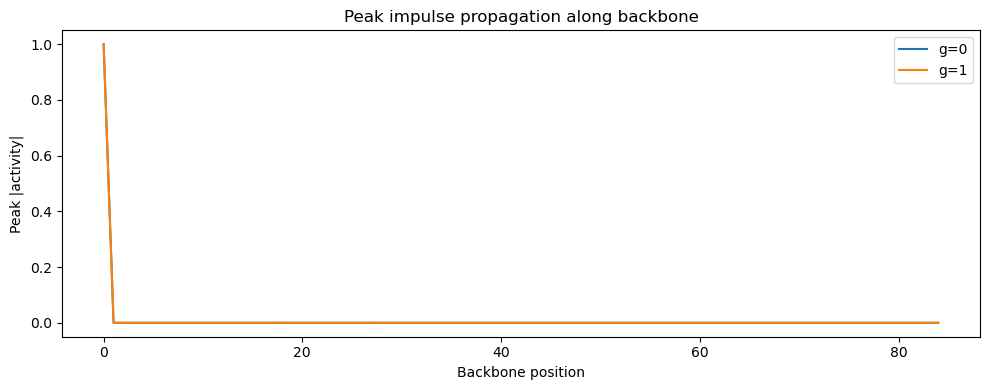

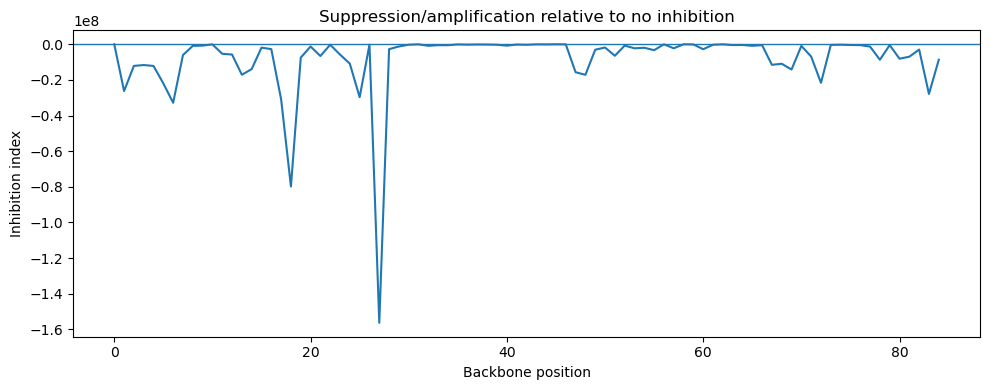

In [12]:

plt.figure(figsize=(10, 4))
plt.plot(m0["backbone_position"], m0["peak_abs"], label="g=0")
plt.plot(m1["backbone_position"], m1["peak_abs"], label="g=1")
plt.xlabel("Backbone position")
plt.ylabel("Peak |activity|")
plt.title("Peak impulse propagation along backbone")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(m1["backbone_position"], m1["inhibition_index_vs_g0"])
plt.axhline(0, linewidth=1)
plt.xlabel("Backbone position")
plt.ylabel("Inhibition index")
plt.title("Suppression/amplification relative to no inhibition")
plt.tight_layout()
plt.show()


## 5. Sweep inhibitory strength

In [13]:

G_VALUES = np.linspace(0.0, 2.0, 21)
terminal_i = backbone_idx[-1]

sweep_rows = []
for g in G_VALUES:
    A = system_matrix(g=g)
    eig = eigvals(A)
    spectral_abscissa = np.max(eig.real)

    X = impulse_response(g=g)
    terminal = np.abs(X[:, terminal_i])
    all_backbone = np.abs(X[:, backbone_idx])

    sweep_rows.append({
        "g": g,
        "spectral_abscissa": spectral_abscissa,
        "terminal_peak": terminal.max(),
        "terminal_auc": np.trapz(terminal, times),
        "terminal_t_peak": times[np.argmax(terminal)],
        "backbone_total_auc": np.trapz(all_backbone, times, axis=0).sum(),
    })

sweep = pd.DataFrame(sweep_rows)
display(sweep)


C:\Users\ranic\AppData\Local\Temp\ipykernel_53420\1670798452.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "terminal_auc": np.trapz(terminal, times),
C:\Users\ranic\AppData\Local\Temp\ipykernel_53420\1670798452.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "backbone_total_auc": np.trapz(all_backbone, times, axis=0).sum(),


,g,spectral_abscissa,terminal_peak,terminal_auc,terminal_t_peak,backbone_total_auc
0,0.0,-0.419069,0.000000e+00,0.000000,0.00,1.000202
1,0.1,-0.427323,8.768407e-07,0.000003,2.05,1.000507
2,0.2,-0.435593,1.751071e-06,0.000007,2.05,1.000802
3,0.3,-0.443895,2.623031e-06,0.000010,2.05,1.001087
4,0.4,-0.452242,3.493056e-06,0.000013,2.05,1.001364
5,0.5,-0.460650,4.361477e-06,0.000016,2.05,1.001633
6,0.6,-0.469135,5.228640e-06,0.000019,2.00,1.001894
7,0.7,-0.477711,6.095000e-06,0.000022,2.00,1.002149
8,0.8,-0.486398,6.960714e-06,0.000026,2.00,1.002397
9,0.9,-0.495212,7.826076e-06,0.000029,2.00,1.002639


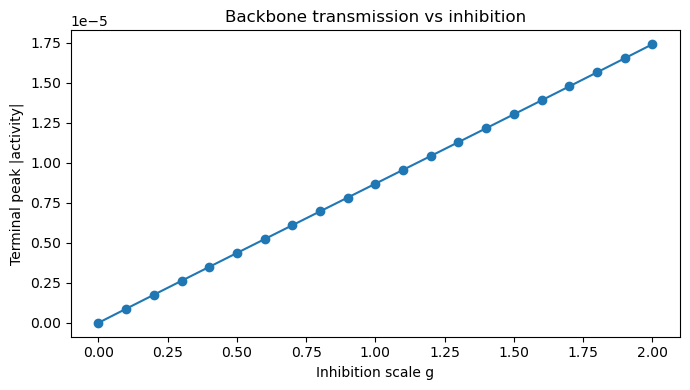

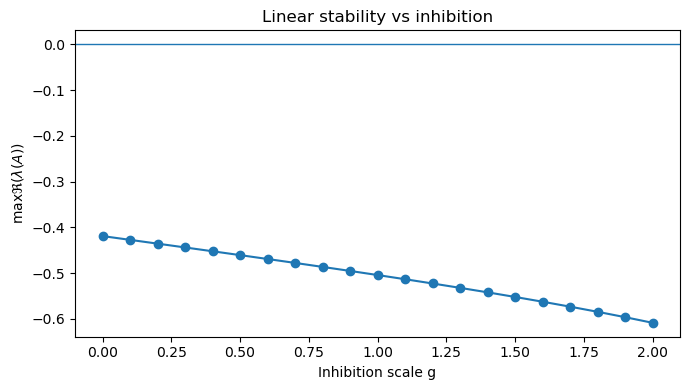

In [14]:

plt.figure(figsize=(7, 4))
plt.plot(sweep["g"], sweep["terminal_peak"], marker="o")
plt.xlabel("Inhibition scale g")
plt.ylabel("Terminal peak |activity|")
plt.title("Backbone transmission vs inhibition")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(sweep["g"], sweep["spectral_abscissa"], marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Inhibition scale g")
plt.ylabel(r"$\max \Re(\lambda(A))$")
plt.title("Linear stability vs inhibition")
plt.tight_layout()
plt.show()



## 6. Global transient amplification

Eigenvalues describe asymptotic stability, but a directed non-normal network can transiently amplify perturbations even when all eigenvalues have negative real part.

We compute

\[
G(t)=\|e^{A t}\|_2,
\qquad
G_{\max}=\max_t G(t).
\]

This exact calculation is more expensive, so it is evaluated only for selected \(g\) values on a coarse time grid.


,g,G_max,t_at_G_max,spectral_abscissa,numerical_abscissa
0,0.0,24.632114,1.2,-0.419069,27.199231
1,0.5,24.206815,1.2,-0.460650,27.189260
2,1.0,23.799705,1.2,-0.504174,27.179323
3,1.5,23.410115,1.2,-0.552056,27.169420
4,2.0,23.037408,1.2,-0.608535,27.159552


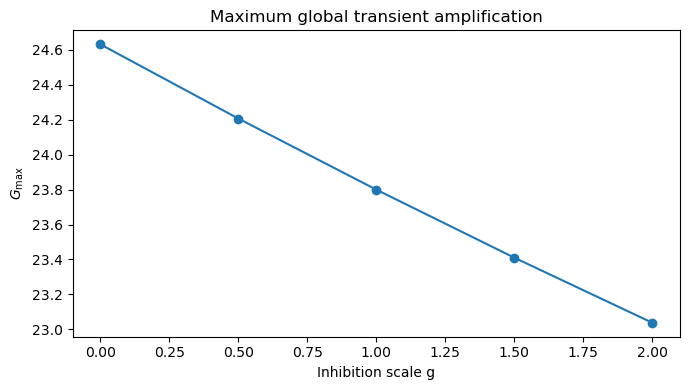

In [15]:

TRANSIENT_G = [0.0, 0.5, 1.0, 1.5, 2.0]
TRANSIENT_TIMES = np.linspace(0.0, 8.0, 41)

transient_rows = []
for g in TRANSIENT_G:
    A = system_matrix(g=g)
    gains = []
    for t in TRANSIENT_TIMES:
        M = expm(A * t)
        gains.append(svdvals(M)[0])
    gains = np.asarray(gains)
    transient_rows.append({
        "g": g,
        "G_max": gains.max(),
        "t_at_G_max": TRANSIENT_TIMES[np.argmax(gains)],
        "spectral_abscissa": np.max(eigvals(A).real),
        "numerical_abscissa": np.max(np.linalg.eigvalsh((A + A.T)/2)),
    })

transient = pd.DataFrame(transient_rows)
display(transient)

plt.figure(figsize=(7, 4))
plt.plot(transient["g"], transient["G_max"], marker="o")
plt.xlabel("Inhibition scale g")
plt.ylabel(r"$G_{\max}$")
plt.title("Maximum global transient amplification")
plt.tight_layout()
plt.show()



## 7. Inhibitory-neuron ablation

For each source neuron \(j\), remove its outgoing inhibitory effects by zeroing column \(j\) of \(W_I\), then measure the change in terminal peak transmission:

\[
\Delta_j =
F(W_I^{(-j)})-F(W_I).
\]

Positive \(\Delta_j\) means removing that neuron's inhibition increases terminal propagation, so the intact neuron suppresses the backbone endpoint.


In [16]:

ABLATION_G = 1.0
baseline_X = impulse_response(g=ABLATION_G)
baseline_terminal_peak = np.abs(baseline_X[:, terminal_i]).max()

node_ablation_rows = []
for j, lab in enumerate(labels):
    if not np.any(W_I[:, j] > 0):
        continue

    WI_abl = W_I.copy()
    WI_abl[:, j] = 0.0

    X = impulse_response(g=ABLATION_G, W_I_=WI_abl)
    terminal_peak = np.abs(X[:, terminal_i]).max()

    node_ablation_rows.append({
        "node": lab,
        "backbone_position": position.get(lab, np.nan),
        "inhibitory_out_degree": int((W_I[:, j] > 0).sum()),
        "inhibitory_out_strength": W_I[:, j].sum(),
        "terminal_peak_after_ablation": terminal_peak,
        "delta_terminal_peak": terminal_peak - baseline_terminal_peak,
    })

node_ablation = pd.DataFrame(node_ablation_rows).sort_values(
    "delta_terminal_peak", ascending=False
)

display(node_ablation.head(20))


,node,backbone_position,inhibitory_out_degree,inhibitory_out_strength,terminal_peak_after_ablation,delta_terminal_peak
25,CA1 Trilaminar,27,27,0.117428,0.000009,6.052205e-08
3,CA1 Basket CCK+,3,9,0.300739,0.000009,6.097763e-09
6,CA1 Horizontal Basket,6,9,0.111922,0.000009,4.537866e-09
2,CA1 Basket,2,9,0.132680,0.000009,3.878163e-09
23,CA1 SO SO,25,19,0.039969,0.000009,4.341883e-10
14,CA1 Oriens Alveus,14,20,0.044641,0.000009,2.296650e-10
31,CA3 Basket,34,5,0.121841,0.000009,2.033373e-10
32,CA3 Basket CCK+,35,5,0.374943,0.000009,1.377802e-10
5,CA1 Horizontal Axo Axonic,5,2,0.000147,0.000009,1.187858e-10
19,CA1 R Receiving Apical Targeting,20,18,0.037101,0.000009,3.851244e-11


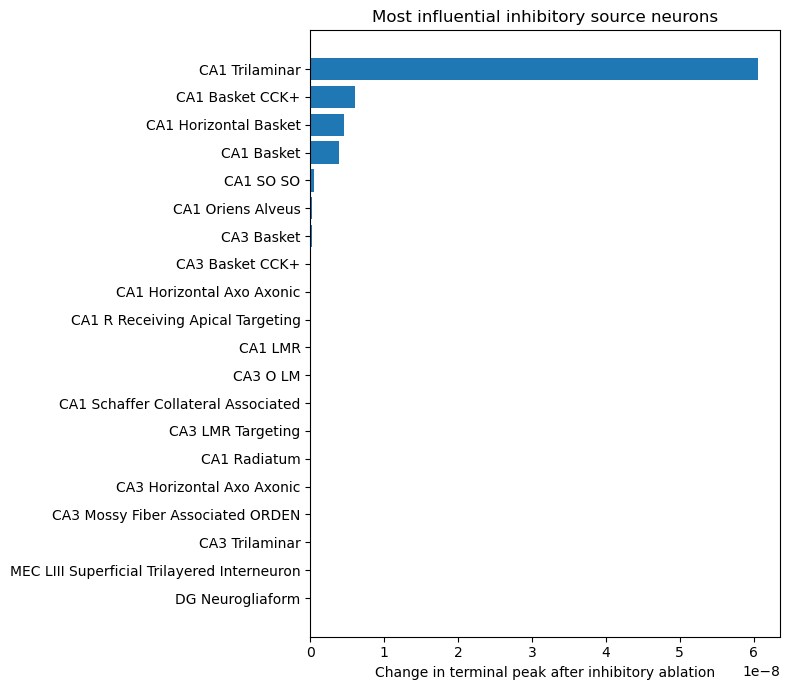

In [17]:

top = node_ablation.head(20).iloc[::-1]
plt.figure(figsize=(8, 7))
plt.barh(top["node"], top["delta_terminal_peak"])
plt.xlabel("Change in terminal peak after inhibitory ablation")
plt.title("Most influential inhibitory source neurons")
plt.tight_layout()
plt.show()


## 8. Inhibitory-edge ablation

In [18]:

# Finite-difference edge ablation is expensive. Analyze the strongest inhibitory edges first.
TOP_K_EDGE_ABLATIONS = 50

targets, sources = np.where(W_I > 0)
edge_table = pd.DataFrame({
    "source_idx": sources,
    "target_idx": targets,
    "source": [labels[j] for j in sources],
    "target": [labels[i] for i in targets],
    "inhibitory_magnitude": W_I[targets, sources],
}).sort_values("inhibitory_magnitude", ascending=False).head(TOP_K_EDGE_ABLATIONS)

edge_ablation_rows = []
for r in edge_table.itertuples(index=False):
    WI_abl = W_I.copy()
    WI_abl[r.target_idx, r.source_idx] = 0.0
    X = impulse_response(g=ABLATION_G, W_I_=WI_abl)
    terminal_peak = np.abs(X[:, terminal_i]).max()

    edge_ablation_rows.append({
        "source": r.source,
        "target": r.target,
        "inhibitory_magnitude": r.inhibitory_magnitude,
        "delta_terminal_peak": terminal_peak - baseline_terminal_peak,
    })

edge_ablation = pd.DataFrame(edge_ablation_rows).sort_values(
    "delta_terminal_peak", ascending=False
)
display(edge_ablation.head(20))


,source,target,inhibitory_magnitude,delta_terminal_peak
23,CA1 Back Projection,CA3 Basket,0.037142,3.096470e-10
33,CA1 Basket CCK+,CA1 Bistratified,0.031090,1.554917e-11
43,CA1 Trilaminar,CA1 Perforant Path Associated QuadD,0.025380,1.494559e-11
44,CA1 Back Projection,CA1 LMR,0.025373,8.387093e-12
40,CA1 Basket CCK+,CA1 OR LM,0.027942,7.277729e-12
10,CA1 Back Projection,CA1 Perforant Path Associated QuadD,0.053960,5.365625e-12
20,CA1 Bistratified,CA1 Perforant Path Associated QuadD,0.038966,1.849256e-12
37,CA1 Horizontal Basket,CA1 Radial Trilaminar,0.028796,1.408049e-12
8,CA1 Basket CCK+,CA1 Radial Trilaminar,0.063039,1.119501e-12
46,CA2 Wide Arbor Basket,CA3 Basket CCK+,0.024174,8.080788e-13



## 9. Inhibitory motifs relative to the backbone

Define the backbone coordinate \(p(v_k)=k\). For an inhibitory edge \(j\to i\),

\[
d_{ji}=p(i)-p(j).
\]

- \(d>0\): forward/feedforward relative to the backbone
- \(d<0\): backward/feedback relative to the backbone
- large \(|d|\): long-range relative to the backbone


In [19]:

motif_rows = []
for i, j in zip(targets, sources):
    source = labels[j]
    target = labels[i]
    if source not in position or target not in position:
        continue
    d = position[target] - position[source]
    motif = "feedforward" if d > 0 else ("feedback" if d < 0 else "self")
    motif_rows.append({
        "source": source,
        "target": target,
        "source_position": position[source],
        "target_position": position[target],
        "distance": d,
        "abs_distance": abs(d),
        "motif": motif,
        "inhibitory_magnitude": W_I[i, j],
    })

motifs = pd.DataFrame(motif_rows)
display(motifs.groupby("motif").agg(
    n_edges=("motif", "size"),
    mean_magnitude=("inhibitory_magnitude", "mean"),
    median_distance=("distance", "median"),
    mean_abs_distance=("abs_distance", "mean"),
))


,n_edges,mean_magnitude,median_distance,mean_abs_distance
motif,,,,
feedback,476,0.004817,-9.0,11.128151
feedforward,387,0.006217,8.0,12.568475


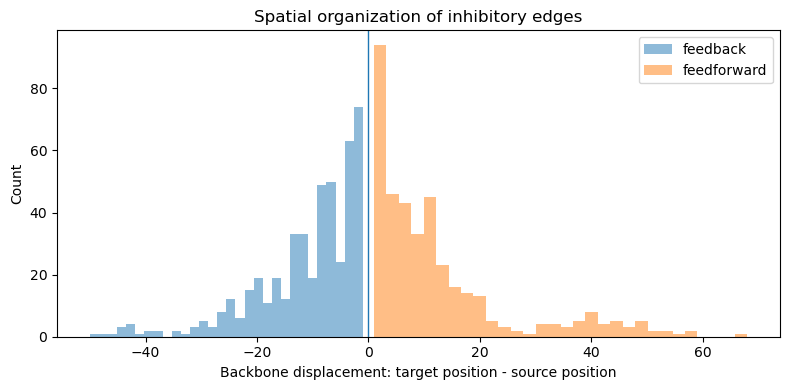

In [20]:

plt.figure(figsize=(8, 4))
for name, grp in motifs.groupby("motif"):
    plt.hist(grp["distance"], bins=30, alpha=0.5, label=name)
plt.axvline(0, linewidth=1)
plt.xlabel("Backbone displacement: target position - source position")
plt.ylabel("Count")
plt.title("Spatial organization of inhibitory edges")
plt.legend()
plt.tight_layout()
plt.show()



## 10. Null model for inhibitory placement

The following null preserves, for each source neuron:

- its number of inhibitory outgoing edges,
- its multiset of inhibitory weights,
- its identity as an inhibitory source,

while randomizing inhibitory **targets**.

It does **not** preserve inhibitory target in-degree, so interpret this as a first-order spatial-placement null rather than a full directed degree-preserving rewiring.


Observed terminal peak: 8.69137e-06
Null mean ± SD: 8.16921e-06 ± 2.21152e-05
Z score: 0.024


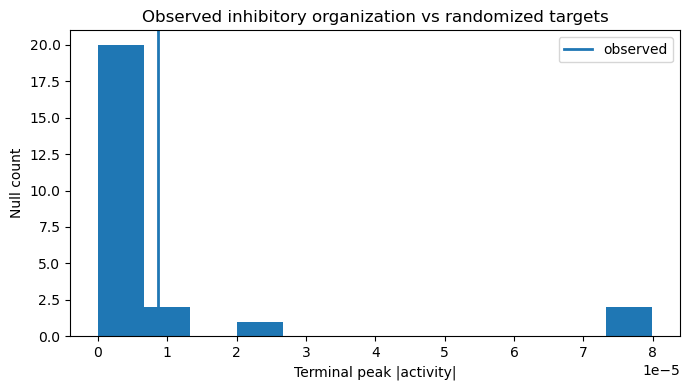

In [21]:

RNG = np.random.default_rng(2026)
N_NULL = 25
NULL_G = 1.0

def randomize_inhibitory_targets(WI, rng):
    WI_null = np.zeros_like(WI)
    for j in range(n):
        existing_targets = np.flatnonzero(WI[:, j] > 0)
        weights = WI[existing_targets, j].copy()
        k = len(weights)
        if k == 0:
            continue
        allowed = np.array([i for i in range(n) if i != j])
        new_targets = rng.choice(allowed, size=k, replace=False)
        rng.shuffle(weights)
        WI_null[new_targets, j] = weights
    return WI_null

observed_metric = baseline_terminal_peak

null_metrics = []
for b in range(N_NULL):
    WI_null = randomize_inhibitory_targets(W_I, RNG)
    Xnull = impulse_response(g=NULL_G, W_I_=WI_null)
    null_metrics.append(np.abs(Xnull[:, terminal_i]).max())

null_metrics = np.asarray(null_metrics)
null_mean = null_metrics.mean()
null_sd = null_metrics.std(ddof=1)
z = (observed_metric - null_mean) / (null_sd + 1e-12)

print(f"Observed terminal peak: {observed_metric:.6g}")
print(f"Null mean ± SD: {null_mean:.6g} ± {null_sd:.6g}")
print(f"Z score: {z:.3f}")

plt.figure(figsize=(7, 4))
plt.hist(null_metrics, bins=12)
plt.axvline(observed_metric, linewidth=2, label="observed")
plt.xlabel("Terminal peak |activity|")
plt.ylabel("Null count")
plt.title("Observed inhibitory organization vs randomized targets")
plt.legend()
plt.tight_layout()
plt.show()



## 11. Suggested interpretation checklist

Use the analyses jointly rather than interpreting a single statistic.

- **Propagation profile:** Where along the backbone does inhibition most strongly attenuate or amplify the response?
- **Strength sweep:** Is the response monotone in \(g\), or are there non-monotone regimes?
- **Stability:** Does inhibition move the spectral abscissa toward or away from zero?
- **Transient gain:** Can inhibition reduce asymptotic instability while preserving or increasing transient amplification?
- **Node ablations:** Which inhibitory sources function as dynamical gates?
- **Edge ablations:** Which specific inhibitory projections have the greatest leverage?
- **Backbone geometry:** Are influential inhibitory edges preferentially feedforward, feedback, or long-range?
- **Null model:** Is the observed placement of inhibition special beyond inhibitory out-strength/degree?

### Important modeling caveats

1. A linear model is a first-order approximation; it does not include saturation, thresholds, refractory behavior, synaptic delays, or separate E/I population dynamics.
2. A negative matrix entry is an inhibitory **effective interaction** unless cell identity independently supports an inhibitory-neuron interpretation.
3. If neuron types are known, enforce Dale-consistent sign structure before making neuron-level claims.
4. For nonlinear follow-up, a Wilson–Cowan or firing-rate model is a natural next step.
5. If conduction/synaptic delays are important, replace the ODE with a delay differential equation or delayed neural-mass model.


## 12. Export key result tables

In [22]:

RESULT_DIR = Path("/mnt/data/connectome_inhibition_results")
RESULT_DIR.mkdir(exist_ok=True)

m1.to_csv(RESULT_DIR / "backbone_metrics_g1.csv", index=False)
sweep.to_csv(RESULT_DIR / "inhibition_sweep.csv", index=False)
transient.to_csv(RESULT_DIR / "transient_gain.csv", index=False)
node_ablation.to_csv(RESULT_DIR / "inhibitory_node_ablation.csv", index=False)
edge_ablation.to_csv(RESULT_DIR / "inhibitory_edge_ablation.csv", index=False)
motifs.to_csv(RESULT_DIR / "inhibitory_backbone_motifs.csv", index=False)

print("Saved result tables to:", RESULT_DIR)


Saved result tables to: \mnt\data\connectome_inhibition_results
